In [ ]:
### Graphs from the computational section
# Libraries ------------------------

import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from scipy import stats
import mesa

# Plotting settings
import matplotlib.ticker as mtick
from helpers import plot_all_agent_graphs
# Graphs font
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': '#f97743',
    'Neutral': '#2f6edd',
    'Pro - environment': '#28b36a'
}
sns.set_palette(["#8E44AD", "#C08081", "#f97743", "#2f6edd", "#28b36a", "#333333"])

# Models ------------------------
from model_statusgame import statusgame_model
from one_agent_subclass import OneActiveStatusGameModel



In [57]:
sns.set_palette(["#f97743", "#2f6edd", "#28b36a", "#333333", "#8E44AD", "#C08081"])

In [ ]:
# Model introductory graphs: networks ------
model_intro = statusgame_model(N=100, seed=666, lambda_s=1, memory=5,
        create_network="watts_strogatz", p=1/100, gamma=1/2, k=10, rho=1/3, seed_consumption=True, alpha=1/2, weights=[1/3, 1/3, 1/3])


nx.write_gexf(model_intro.G, "results/initial_network.gexf")


for _ in range(100):
    model_intro.step()
model_intro_df = model_intro.datacollector.get_agent_vars_dataframe().reset_index()

nx.write_gexf(model_intro.G, "results/final_network.gexf")

#model_intro_df.plot(x="index", y="cluster_coefficient") Non-trivial clustering

alpha = 0.001
alpha = 0.25075
alpha = 0.5005
alpha = 0.75025
alpha = 1.0


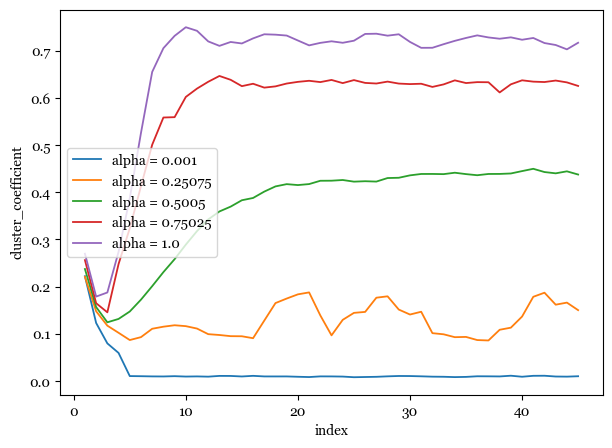

In [3]:
# Graphs to showcase alpha on the network section ------
# Run test with many agents
runs_multi_alpha_all = {}

for alpha in np.linspace(0.001, 1, 5):
    all_agents_alpha = statusgame_model(N=1000, seed=666, lambda_s=1, memory=5,
        create_network="watts_strogatz", p=1/1000, gamma=1, k=5, rho=1/3, seed_consumption=True, alpha=alpha)
    
    for _ in range(45):
        all_agents_alpha.step()

    print(f"alpha = {alpha}")
    runs_multi_alpha_all[alpha] = all_agents_alpha.datacollector.get_model_vars_dataframe().reset_index()

# Store
pd.to_pickle(runs_multi_alpha_all, "results/alpha_runs.pkl")

# Plot
fig, ax = plt.subplots(figsize=(7,5))
for r in range(0,5):
    run = list(runs_multi_alpha_all.keys())[r]
    sns.lineplot(data=runs_multi_alpha_all[run].loc[runs_multi_alpha_all[run].index > 0], x="index", y="cluster_coefficient", label = f"alpha = {run}", ax = ax, linewidth = 1.3)


In [4]:
# Graph 1: Standard behavior of the model
model_prop_neutral = statusgame_model(N=400, seed=666, lambda_s=3/5, memory=20,
        create_network="watts_strogatz", p=1/100, gamma=1/2, k=20, rho=1/2, seed_consumption=True, alpha=1/50, weights=[1/3, 1/3, 1/3])

for _ in range(100):
    model_prop_neutral.step()
model_prop_neutral_df = model_prop_neutral.datacollector.get_agent_vars_dataframe().reset_index()

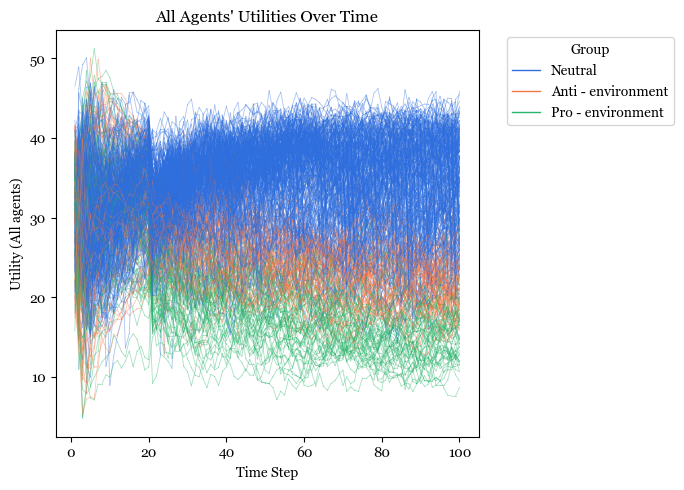

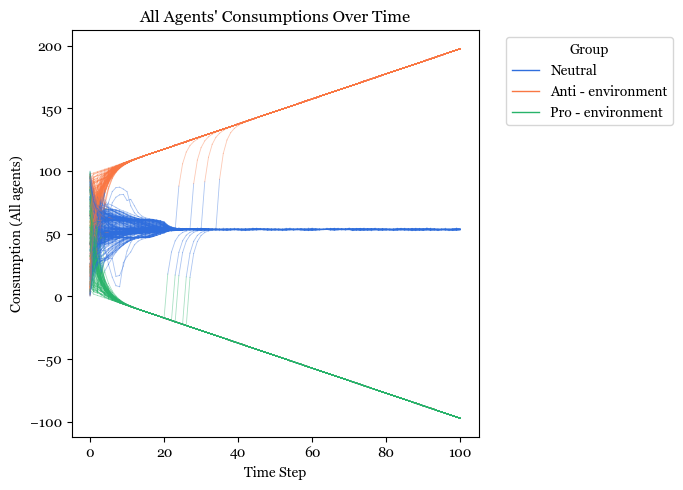

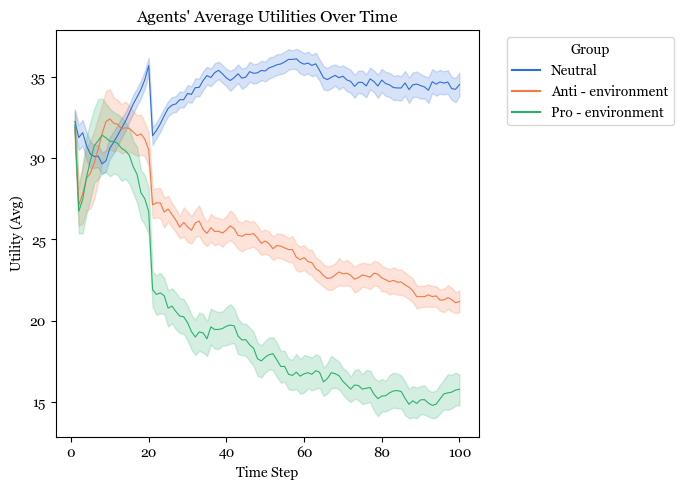

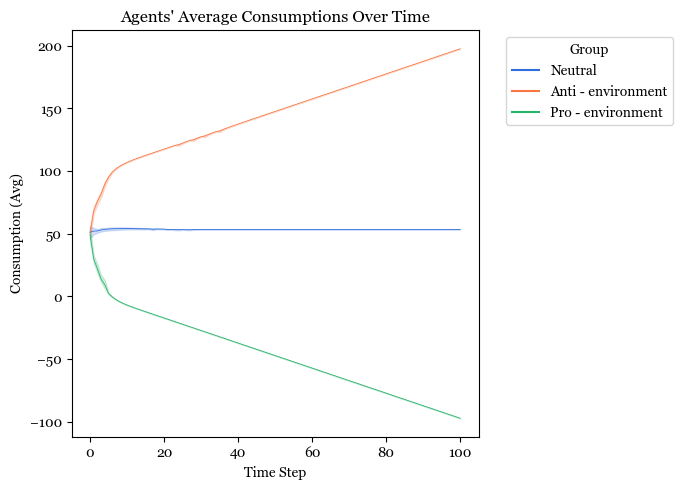

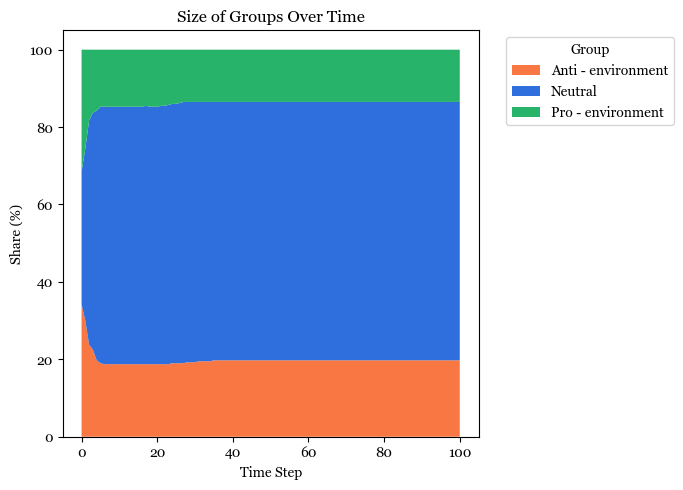

In [5]:
plot_all_agent_graphs(model_prop_neutral_df, color_dict, output_folder="results/fig1_computational", show_plots=True)

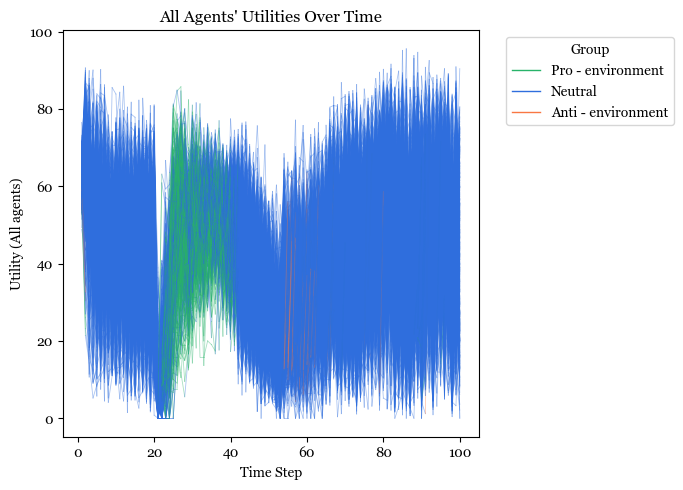

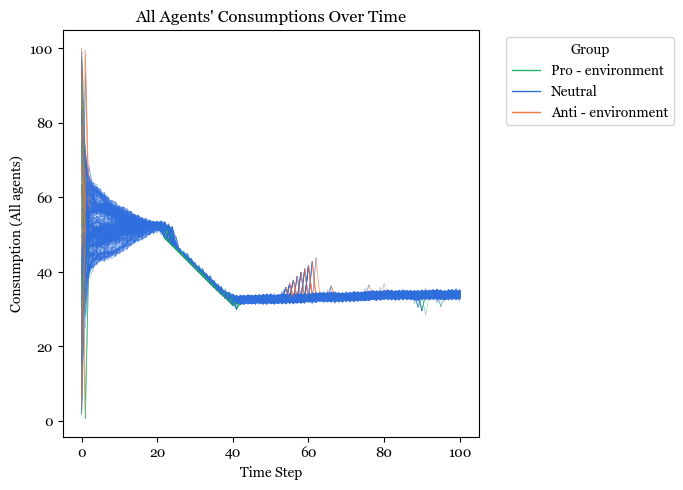

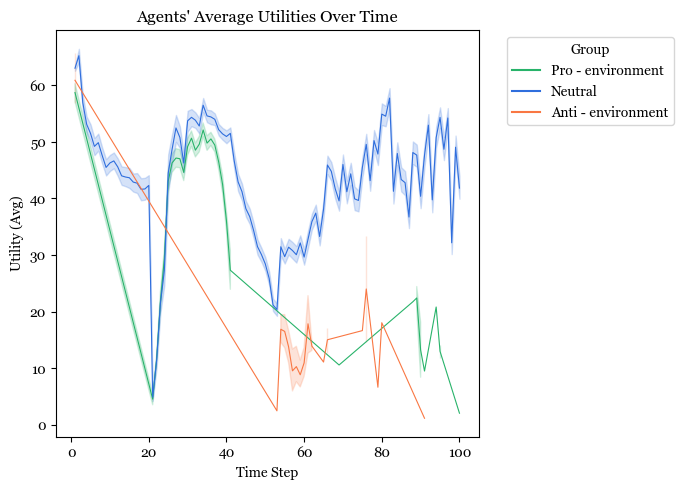

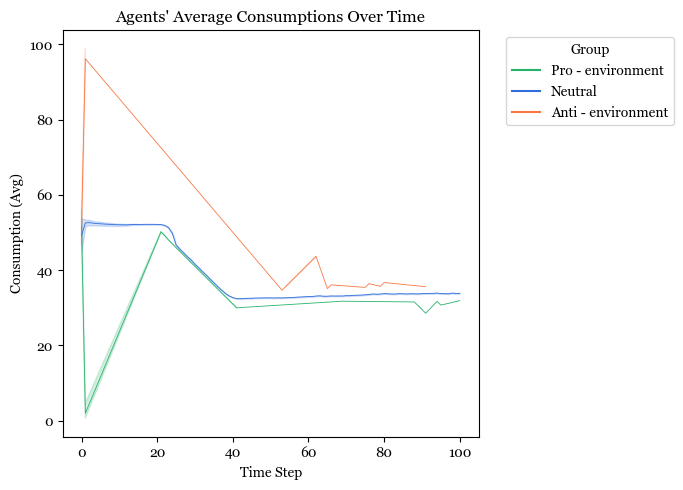

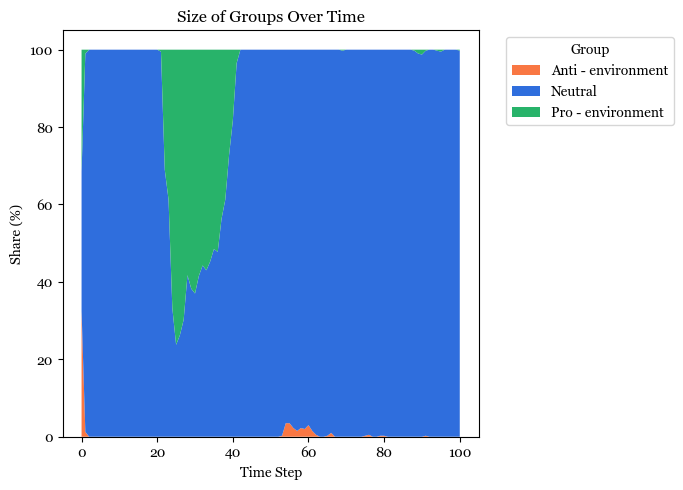

In [6]:
# Graph 2: Extreme initial conditions, everyone becomes neutral quickly 
model_prop_neutral = statusgame_model(N=400, seed=667, lambda_s=1, memory=20,
        create_network="watts_strogatz", p=1/100, gamma=1, k=20, rho=1/3, seed_consumption=True, alpha=1/50, weights=[1/3, 1/3, 1/3])

for _ in range(100):
    model_prop_neutral.step()
model_prop_neutral_df = model_prop_neutral.datacollector.get_agent_vars_dataframe().reset_index()
plot_all_agent_graphs(model_prop_neutral_df, color_dict, output_folder="results/fig2_computational", show_plots=True)

In [7]:
# Graph 3,4,5
# Showcase that the outcome of the model changes depending on the parameters

# 1) Identity 

np.random.seed(666)

params = {"seed": 666, 
          "alpha": 1/5,
          'lambda_s': np.linspace(1/100, 1, 20),
          'N':[100],
          "gamma": 1, 
          "create_network": "watts_strogatz", 
          "k": [3], 
          "p": [1/100],
          "rho": 1/3, 
          "seed_consumption": False, 
          "memory": [10]}

results_batch = mesa.batch_run(
    statusgame_model,
    parameters=params,
    iterations=50,
    max_steps=50,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

#Save
l_results_df = pd.DataFrame(results_batch)
l_results_df.to_csv("results_identity.csv")


  0%|          | 0/1000 [00:00<?, ?it/s]

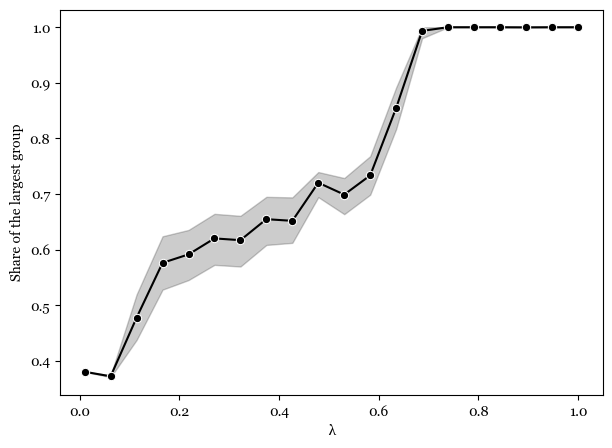

In [8]:
# Plot
# Restructure data and plot
lambda_groups = l_results_df.groupby(["lambda_s", "iteration"])["group"].value_counts(normalize=True).unstack().reset_index().fillna(0)
lambda_groups["Max share"] = lambda_groups[["Anti - environment", "Neutral", "Pro - environment"]].max(axis=1)
fig, ax = plt.subplots(figsize=(7,5))
sns.lineplot(data=lambda_groups, x="lambda_s", y="Max share", 
             color="black", 
             errorbar="ci", estimator="mean",
             marker="o", ax = ax)

ax.set_xlabel("λ") 
ax.set_ylabel("Share of the largest group") 

plt.savefig("results/lambda_thresh.pdf", bbox_inches='tight', dpi=300)

In [ ]:
# 2) Gamma 
np.random.seed(666)


list_possible_gammas = list(np.linspace(0, 0.45, 20))
list_possible_gammas.extend(list(np.linspace(1/2, 1, 10)))

params = {"seed": 666, 
          "alpha": 1/5,
          'lambda_s': 1,
          'N':[50],
          "gamma": np.linspace(0, 1, 20),
          "create_network": "watts_strogatz", 
          "k": [3], 
          "p": [1/100],
          "rho": 1/3, 
          "seed_consumption": False, 
          "memory": [10]}

results_batch = mesa.batch_run(
    statusgame_model,
    parameters=params,
    iterations=50,
    max_steps=50,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

#Save
g_results_df = pd.DataFrame(results_batch)
g_results_df.to_csv("results_gamma.csv")

  0%|          | 0/1000 [00:00<?, ?it/s]

/Users/santiagoherreragarcia/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/santiagoherreragarcia/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/santiagoherreragarcia/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/santiagoherreragarcia/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/santiagoherreragarcia/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/santiagoherreragarcia/anaconda3/lib/python3.1

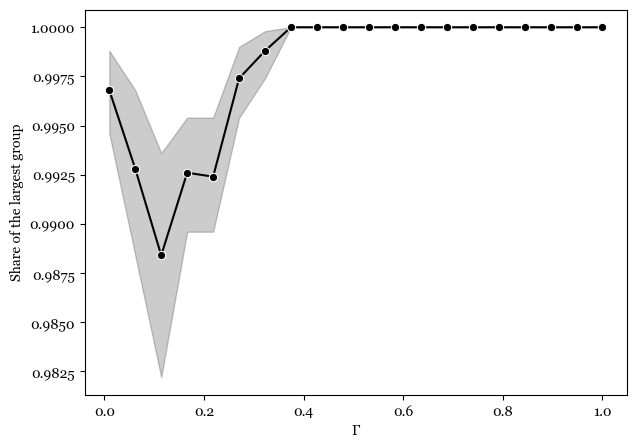

In [10]:
# Plot
# Restructure data and plot
gamma_groups = g_results_df.groupby(["gamma", "iteration"])["group"].value_counts(normalize=True).unstack().reset_index().fillna(0)
gamma_groups["Max share"] = gamma_groups[["Anti - environment", "Neutral", "Pro - environment"]].max(axis=1)
fig, ax = plt.subplots(figsize=(7,5))
sns.lineplot(data=gamma_groups, x="gamma", y="Max share", 
             color="black", 
             errorbar="ci", estimator="mean",
             marker="o", ax = ax)

ax.set_xlabel("Γ") 
ax.set_ylabel("Share of the largest group") 
plt.savefig("results/gamma_thresh.pdf", bbox_inches='tight', dpi=300)

In [ ]:
# 3) Rho, t and alpha 
np.random.seed(666)

params = {"seed": 666, 
          "alpha": np.linspace(0, 1, 15),
          'lambda_s': 1,
          'N':[300],
          "gamma": 1/10,
          "create_network": "watts_strogatz", 
          "k": [5], 
          "p": [1/100],
          "rho": np.linspace(0, 1, 15),
          "seed_consumption": False, 
          "memory": [1,5,15,30], 
          "wait_gamma": True}

results_batch = mesa.batch_run(
    statusgame_model,
    parameters=params,
    iterations=1, # To speed up
    max_steps=50,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

#Save
net_results_df = pd.DataFrame(results_batch)
net_results_df.to_csv("results_network.csv")

  0%|          | 0/16 [00:00<?, ?it/s]

/Users/santiagoherreragarcia/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/santiagoherreragarcia/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [79]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting

# ----------------------------------------------------
# 1) Group the results and compute the fraction of each group
# ----------------------------------------------------
# Suppose your DataFrame is called net_results_df and contains:
#   - "alpha"
#   - "rho"
#   - "iteration"
#   - "group" (Pro - environment, Neutral, Anti - environment)
#   - Possibly many other columns

grouped = (
    net_results_df.loc[net_results_df.memory  == 5]
    .groupby(["alpha", "rho", "iteration"])["group"]
    .value_counts(normalize=True)   # gives fraction in each group
    .unstack(fill_value=0)          # create separate columns for each group
    .reset_index()
)

# ----------------------------------------------------
# 2) Compute the max share across the three groups
# ----------------------------------------------------
# Adjust the column names below if your group labels differ
group_columns = ["Pro - environment", "Neutral", "Anti - environment"]
grouped["max_share"] = grouped[group_columns].max(axis=1)

# ----------------------------------------------------
# 3) Average over all iterations so each (alpha, rho) has one value
# ----------------------------------------------------
agg_df = (
    grouped
    .groupby(["alpha", "rho"], as_index=False)["max_share"]
    .mean()
)

# ----------------------------------------------------
# 4) Pivot to get a 2D grid of Z-values
# ----------------------------------------------------
# Sort alpha and rho so meshgrid is created in ascending order
alpha_vals = np.sort(agg_df["alpha"].unique())
rho_vals   = np.sort(agg_df["rho"].unique())

# Create meshgrid (X, Y)
A, R = np.meshgrid(alpha_vals, rho_vals)

# Pivot your aggregated DataFrame to get Z
pivoted = agg_df.pivot(index="rho", columns="alpha", values="max_share")
Z = pivoted.reindex(index=rho_vals, columns=alpha_vals).values

# ----------------------------------------------------
# 5) Plot: surface or wireframe
# ----------------------------------------------------
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

# Option A: surface plot
surf = ax.plot_surface(A, R, Z, cmap="YlGnBu", edgecolor="none", alpha=0.9, vmin=0, vmax=1)

# Option B (alternative): wireframe plot
# ax.plot_wireframe(A, R, Z, color="black", linewidth=0.5)

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\rho$")
ax.set_zlabel("")
ax.set_zlim(0, 1.01)

fig.colorbar(surf, shrink=0.5, aspect=10, label="Share of the largest group")
#plt.title("Largest Group Share vs. alpha vs. rho")
plt.show()


KeyError: "None of [Index(['Pro - environment', 'Neutral', 'Anti - environment'], dtype='object', name='group')] are in the [columns]"

In [70]:
from matplotlib.colors import LinearSegmentedColormap, rgb_to_hsv, hex2color
# Tus colores originales

colores_hex = ["#2f6edd", "#C08081", "#8E44AD"]

# Crear un colormap suave con transiciones graduales entre los colores ordenados
cmap_secuencial = LinearSegmentedColormap.from_list("personalizado_secuencial", colores_hex, N=256)


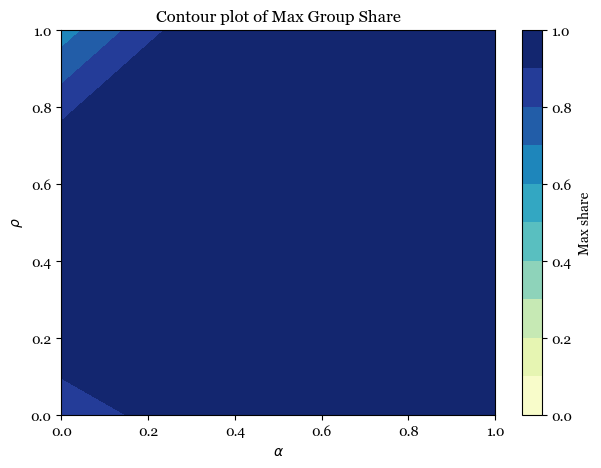

In [76]:
# Refine datasets
grouped = (
    net_results_df.loc[net_results_df.memory  == 15]
    .groupby(["alpha", "rho", "iteration"])["group"]
    .value_counts(normalize=True)   # gives fraction in each group
    .unstack(fill_value=0)          # create separate columns for each group
    .reset_index()
)

group_columns = ["Pro - environment", "Neutral", "Anti - environment"]
grouped["max_share"] = grouped[group_columns].max(axis=1)

# Average across iterations
agg_df = (
    grouped
    .groupby(["alpha", "rho"], as_index=False)["max_share"]
    .mean()
)

# Sort alpha and rho so meshgrid is created in ascending order
alpha_vals = np.sort(agg_df["alpha"].unique())
rho_vals   = np.sort(agg_df["rho"].unique())

# Create meshgrid (X, Y)
A, R = np.meshgrid(alpha_vals, rho_vals)

# Pivot your aggregated DataFrame to get Z
pivoted = agg_df.pivot(index="rho", columns="alpha", values="max_share")
Z = pivoted.reindex(index=rho_vals, columns=alpha_vals).values


# Plot ------------------

fig, ax = plt.subplots(figsize=(7,5))

# Filled contour
levels = np.linspace(0, 1, 11)
cs = ax.contourf(A, R, Z, levels = levels, cmap="YlGnBu")

# Add colorbar (especially if using contourf)
fig.colorbar(cs, ax=ax, label="Max share")

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\rho$")
ax.set_title("Contour plot of Max Group Share")

plt.show()